In [1]:
import Auto_paint_self
import numpy as np

In [2]:
#打开nc文件
def open_data_nc(ncmode,filename,v_name,iftime,timename,timestart,timeend,iflon,lonname,iflat,latname,latlow,lattop,lonleft,lonright,latresolution,lonresolution,ifexper,iflevel,levelname,level,changeresolution=1,timespace=1,ifchange_west_east='no',ifinterpolate='no'):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from netCDF4 import Dataset as net
    import xarray as xr
    from datetime import datetime,timedelta
    from dateutil.relativedelta import relativedelta
    import os
    from wrf import getvar,interplevel
    
    plt.rcParams['font.sans-serif']=['SimHei'] #正常显示中文
    plt.rcParams['axes.unicode_minus']=False #正常显示正负号
    if ncmode == 'one':
        file = xr.open_dataset(filename)
        if ifinterpolate == 'yes':
            inter = str('file.interp('+latname+'=np.arange('+str(latlow)+','+str(lattop+latresolution)+','+str(latresolution)+'),'+lonname+'=np.arange('+str(lonleft)+','+str(lonright+lonresolution)+','+str(lonresolution)+'))')
            files=eval(inter)
            file = files
        if iftime  == 'yes' or iftime == 'self':
            times = np.array(file[timename])
        if iflon == 'yes':
            lon = np.array(file[lonname])
        if iflat == 'yes':
            lat = np.array(file[latname])
        v = file[v_name]
        if iflevel != 'no':
            levels = np.array(file[levelname])
    elif ncmode == 'more_time' or ncmode =='more_level':
        direc = os.listdir(filename)
        path = []
        file = []
        v = []
        lat = []
        lon = []
        times = []
        levels = []
        for i in range(len(direc)):
            if filename[-1] == '/':  
                path.append(filename+str(direc[i]))
            else:
                path.append(filename+'/'+str(direc[i]))
            file_xr = xr.open_dataset(path[i])
            if ifinterpolate == 'yes':
                inter = str('file_xr.interp('+latname+'=np.arange('+str(latlow)+','+str(lattop)+','+str(latresolution)+'),'+lonname+'=np.arange('+str(lonleft)+','+str(lonright)+','+str(lonresolution)+'))')
                files=eval(inter)
                file_xr = files
            file.append(file_xr)
            if ncmode == 'more_time':
                vs=np.array(file[i][v_name])
                if iftime =='yes':
                    timelist=np.array(file[i][timename])
                if i != 0:
                    if iftime =='yes':
                        v=np.concatenate((v,vs))
                        times=np.concatenate((times,timelist))
                    elif iftime =='create':
                        if iflevel !='no':
                            if iflat !='no':
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1],vs.shape[2]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                            else:
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0]))
                        else:
                            if iflat !='no':
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0]))
                            else:
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0]))
                                else:
                                    vs = vs.reshape((1))
                        v=np.concatenate((v,vs))
                else:
                    if iftime == 'create':
                        if iflevel !='no':
                            if iflat !='no':
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1],vs.shape[2]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                            else:
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0]))
                        else:
                            if iflat !='no':
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0]))
                            else:
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0]))
                                else:
                                    vs = vs.reshape((1))
                        v=vs
                    elif iftime == 'yes':
                        v = vs
                        times=timelist
            if ncmode == 'more_level':
                if iflevel == 'create':
                    vs=np.array(file[i][v_name])
                    levels=level
                elif iflevel == 'yes' or iflevel =='all' or iflevel =='self' or iflevel =='selfchose':
                    if iftime !='no':
                        if iflat !='no':
                            if iflon !='no':
                                vs=np.array(file[i][v_name]).transpose(1,0,2,3)
                            else:
                                vs=np.array(file[i][v_name]).transpose(1,0,2)
                        else:
                            if iflon !='no':
                                vs=np.array(file[i][v_name]).transpose(1,0,2)
                            else:
                                vs=np.array(file[i][v_name]).transpose(1,0)
                    levellist=np.array(file[i][levelname])      
                if i != 0:
                    if iflevel == 'yes' or iflevel =='all' or iflevel =='self' or iflevel =='selfchose':
                        v=np.concatenate((v,vs))
                        levels=np.concatenate((levels,levellist))
                    elif iflevel =='create':
                        if iftime !='no':
                            if iflat !='no':
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1],vs.shape[2]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                            else:
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0]))
                        else:
                            if iflat !='no':
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0]))
                            else:
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0]))
                                else:
                                    vs = vs.reshape((1))
                        v=np.concatenate((v,vs))
                else:
                    if iflevel == 'create':
                        if iftime !='no':
                            if iflat !='no':
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1],vs.shape[2]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                            else:
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0]))
                        else:
                            if iflat !='no':
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0]))
                            else:
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0]))
                                else:
                                    vs = vs.reshape((1))
                        v=vs
                    elif iflevel == 'yes' or iflevel =='all' or iflevel =='self' or iflevel =='selfchose':
                        v=vs
                        levels=levellist
        if ncmode == 'more_time':
            if iflon =='yes':
                lon = file[0][lonname]
            if iflat =='yes':
                lat = file[0][latname]
            if iflevel != 'no':
                levels = np.array(file[0][levelname])
        if ncmode == 'more_level':
            if iflon =='yes':
                lon = file[0][lonname]
            if iflat =='yes':
                lat = file[0][latname]
            if iftime != 'no':
                times = np.array(file[0][timename])
            if iftime !='no':
                if iflat !='no':
                    if iflon !='no':
                        v=v.transpose(1,0,2,3)
                    else:
                        v=v.transpose(1,0,2)
                else:
                    if iflon !='no':
                        v=v.transpose(1,0,2)
                    else:
                        v=v.transpose(1,0)
    elif ncmode == 'one_wrf':
        file = xr.open_dataset(filename)
        ncfile = net(filename)
        times = np.array(file[timename])
        lon = np.array(file[lonname][0,0,:])
        lat = np.array(file[latname][0,:,0])
        if iflevel == 'no':
            v = np.zeros((times.shape[0],lat.shape[0],lon.shape[0]))
            for i in range(times.shape[0]):
                v[i,:,:] = np.array(getvar(ncfile,v_name,i))
        elif iflevel == 'yes':
            levels = np.array(file[levelname])[0,:]
            p = np.zeros((times.shape[0],levels.shape[0],lat.shape[0],lon.shape[0]))
            v = np.zeros((times.shape[0],levels.shape[0],lat.shape[0],lon.shape[0]))
            for i in range(times.shape[0]):
                if v_name == 'U':
                    v[i,:,:,:] = np.array(getvar(ncfile,v_name,i))[:,:,:-1]
                elif v_name == 'V':
                    v[i,:,:,:] = np.array(getvar(ncfile,v_name,i))[:,:-1,:]
                elif v_name == 'W' or v_name == 'PH' or v_name == 'PHB':
                    v[i,:,:,:] = np.array(getvar(ncfile,v_name,i))[:-1,:,:]
                else:
                    v[i,:,:,:] = np.array(getvar(ncfile,v_name,i))
                p[i,:,:,:] = np.array(getvar(ncfile,'pressure',i))
            vs = np.zeros((times.shape[0],lat.shape[0],lon.shape[0]))
            for i in range(times.shape[0]):
                vs[i,:,:] = interplevel(v[i,:,:,:],p[i,:,:,:],level)
        else:
            levels = np.array(file[levelname])[0,:]
            p = np.zeros((times.shape[0],levels.shape[0],lat.shape[0],lon.shape[0]))
            v = np.zeros((times.shape[0],levels.shape[0],lat.shape[0],lon.shape[0]))
            for i in range(times.shape[0]):
                if v_name == 'U':
                    v[i,:,:,:] = np.array(getvar(ncfile,v_name,i))[:,:,:-1]
                elif v_name == 'V':
                    v[i,:,:,:] = np.array(getvar(ncfile,v_name,i))[:,:-1,:]
                elif v_name == 'W' or v_name == 'PH' or v_name == 'PHB':
                    v[i,:,:,:] = np.array(getvar(ncfile,v_name,i))[:-1,:,:]
                else:
                    v[i,:,:,:] = np.array(getvar(ncfile,v_name,i))
                p[i,:,:,:] = np.array(getvar(ncfile,'pressure',i))
            vs = np.zeros((times.shape[0],len(level),lat.shape[0],lon.shape[0]))
            for i in range(times.shape[0]):
                vs[i,:,:,:] = interplevel(v[i,:,:,:],p[i,:,:,:],level)
        if iflevel !='no':
            levels = level
            v = vs
    if iftime =='yes' or iftime == 'create':
        if len(timestart) == 4 :
            if iftime =='yes':
                for i in range(len(times)):
                    if timestart == pd.to_datetime(str(np.array(times[i]))).strftime('%Y'):
                        startpoint = i
                    if timeend == pd.to_datetime(str(np.array(times[i]))).strftime('%Y'):
                        endpoint = i
            if iftime =='create':
                for i in range(v.shape[0]):
                    times.append(datetime(int(pd.to_datetime(str(timestart)).strftime('%Y')),int(pd.to_datetime(str(timestart)).strftime('%m')),int(pd.to_datetime(str(timestart)).strftime('%d')))+ timespace*i * relativedelta(years=+1))
                    times[i]=pd.to_datetime(str(times[i])).strftime('%Y-%m-%d')
                times = np.array(times,dtype = np.datetime64)
        elif len(timestart) == 7 :
            if iftime =='yes':
                for i in range(len(times)):
                    if timestart == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m'):
                        startpoint = i
                    if timeend == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m'):
                        endpoint = i
            if iftime =='create':
                for i in range(v.shape[0]):
                    times.append(datetime(int(pd.to_datetime(str(timestart)).strftime('%Y')),int(pd.to_datetime(str(timestart)).strftime('%m')),int(pd.to_datetime(str(timestart)).strftime('%d')))+ timespace*i * relativedelta(months=+1))
                    times[i]=pd.to_datetime(str(times[i])).strftime('%Y-%m-%d')
                times = np.array(times,dtype = np.datetime64)
        elif len(timestart) == 10 :
            if iftime =='yes':
                for i in range(len(times)):
                    if timestart == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d'):
                        startpoint = i
                    if timeend == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d'):
                        endpoint = i
            if iftime =='create':
                for i in range(v.shape[0]):
                    times.append(datetime(int(pd.to_datetime(str(timestart)).strftime('%Y')),int(pd.to_datetime(str(timestart)).strftime('%m')),int(pd.to_datetime(str(timestart)).strftime('%d')))+ timespace*i * timedelta(days=1))
                    times[i]=pd.to_datetime(str(times[i])).strftime('%Y-%m-%d')
                times = np.array(times,dtype = np.datetime64)
        elif len(timestart) == 13 :
            if iftime =='yes':
                for i in range(len(times)):
                    if timestart == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d-%H'):
                        startpoint = i
                    if timeend == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d-%H'):
                        endpoint = i
            if iftime =='create':
                for i in range(v.shape[0]):
                    times.append(datetime(int(pd.to_datetime(str(timestart)).strftime('%Y')),int(pd.to_datetime(str(timestart)).strftime('%m')),int(pd.to_datetime(str(timestart)).strftime('%d')),int(pd.to_datetime(str(timestart)).strftime('%H')))+ timespace*i * timedelta(hours=1))
                    times[i]=pd.to_datetime(str(times[i])).strftime('%Y-%m-%d %H:%M:%S')
                times = np.array(times,dtype = np.datetime64)
        elif len(timestart) == 16 :
            if iftime =='yes':
                for i in range(len(times)):
                    if timestart == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d-%H-%M'):
                        startpoint = i
                    if timeend == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d-%H-%M'):
                        endpoint = i
            if iftime =='create':
                for i in range(v.shape[0]):
                    times.append(datetime(int(pd.to_datetime(str(timestart)).strftime('%Y')),int(pd.to_datetime(str(timestart)).strftime('%m')),int(pd.to_datetime(str(timestart)).strftime('%d')),int(pd.to_datetime(str(timestart)).strftime('%H')),int(pd.to_datetime(str(timestart)).strftime('%M')))+ timespace*i * timedelta(minutes=1))
                    times[i]=pd.to_datetime(str(times[i])).strftime('%Y-%m-%d %H:%M:%S')
                times = np.array(times,dtype = np.datetime64)
        elif len(timestart) == 19 :
            if iftime =='yes':
                for i in range(len(times)):
                    if timestart == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d-%H-%M-%S'):
                        startpoint = i
                    if timeend == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d-%H-%M-%S'):
                        endpoint = i
            if iftime =='create':
                for i in range(v.shape[0]):
                    times.append(datetime(int(pd.to_datetime(str(timestart)).strftime('%Y')),int(pd.to_datetime(str(timestart)).strftime('%m')),int(pd.to_datetime(str(timestart)).strftime('%d')),int(pd.to_datetime(str(timestart)).strftime('%H')),int(pd.to_datetime(str(timestart)).strftime('%M')),int(pd.to_datetime(str(timestart)).strftime('%S')))+ timespace*i * timedelta(seconds=1))
                    times[i]=pd.to_datetime(str(times[i])).strftime('%Y-%m-%d %H:%M:%S')
                times = np.array(times,dtype = np.datetime64)
    if iftime=='self':
        for i in range(len(times)):
            if timestart == times[i]:
                startpoint = i
            if timeend == times[i]:
                endpoint = i
    if iftime =='yes' or iftime=='self':
        times = times[startpoint:endpoint+1]
    elif iftime =='create':
        startpoint = 0
        endpoint = times.shape[0]
    if iflat == 'yes':
        if float(lat[0])>float(lat[1]):
            lowpoint = int((np.nanmax(lat)-latlow)/latresolution)
            toppoint = int((np.nanmax(lat)-lattop)/latresolution)
        else:
            lowpoint = int((-np.nanmin(lat)+latlow)/latresolution)
            toppoint = int((-np.nanmin(lat)+lattop)/latresolution)
    if iflon == 'yes':
        leftpoint = int((-np.nanmin(lon)+lonleft)/lonresolution)
        rightpoint = int((-np.nanmin(lon)+lonright)/lonresolution)
    if ncmode != 'one_wrf':
        if iflevel == 'yes':
            for i in range(0,len(levels)):
                if int(level) == int(levels[i]):
                    levelpoint = i
            if ifexper == 'yes':
                if float(lat[0])>float(lat[1]):
                    v = v[startpoint:endpoint+1,0,levelpoint,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,::changeresolution,::changeresolution])
                else:
                    v = v[startpoint:endpoint+1,0,levelpoint,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,::changeresolution,::changeresolution])
            elif ifexper ==  'no':
                if iftime != 'no':
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,levelpoint,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,levelpoint,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,levelpoint,leftpoint:rightpoint+1]
                            v = np.array(v[:,::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,levelpoint,toppoint:lowpoint+1]
                                v = np.array(v[:,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,levelpoint,lowpoint:toppoint+1]
                                v = np.array(v[:,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,levelpoint]
                            v = np.array(v)
                else:
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[levelpoint,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[::changeresolution,::changeresolution])
                            else:
                                v = v[levelpoint,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[::changeresolution,::changeresolution])
                        else:
                            v = v[levelpoint,leftpoint:rightpoint+1]
                            v = np.array(v[::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[levelpoint,toppoint:lowpoint+1]
                                v = np.array(v[::changeresolution])
                            else:
                                v = v[levelpoint,lowpoint:toppoint+1]
                                v = np.array(v[::changeresolution])
                        else:
                            v = v[levelpoint]
                            v = np.array(v)
        elif iflevel == 'no':
            if ifexper == 'yes':
                if float(lat[0])>float(lat[1]):
                    v = v[startpoint:endpoint+1,0,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,::changeresolution,::changeresolution])
                else:
                    v = v[startpoint:endpoint+1,0,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,::changeresolution,::changeresolution])
            elif ifexper ==  'no':
                if iftime != 'no':
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,leftpoint:rightpoint+1]
                            v = np.array(v[:,::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,toppoint:lowpoint+1]
                                v = np.array(v[:,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,lowpoint:toppoint+1]
                                v = np.array(v[:,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1]
                            v = np.array(v)
                else:
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[::changeresolution,::changeresolution])
                            else:
                                v = v[lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[::changeresolution,::changeresolution])
                        else:
                            v = v[leftpoint:rightpoint+1]
                            v = np.array(v[::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[toppoint:lowpoint+1]
                                v = np.array(v[::changeresolution])
                            else:
                                v = v[lowpoint:toppoint+1]
                                v = np.array(v[::changeresolution])
                        else:
                            v = None
        elif iflevel == 'all' or iflevel =='create':
            if ifexper == 'yes':
                if float(lat[0])>float(lat[1]):
                    v = v[startpoint:endpoint+1,0,:,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,:,::changeresolution,::changeresolution])
                else:
                    v = v[startpoint:endpoint+1,0,:,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,:,::changeresolution,::changeresolution])
            elif ifexper == 'no':
                if iftime != 'no':
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,:,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,:,::changeresolution,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,:,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,:,::changeresolution,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,:,leftpoint:rightpoint+1]
                            v = np.array(v[:,:,::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,:,toppoint:lowpoint+1]
                                v = np.array(v[:,:,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,:,lowpoint:toppoint+1]
                                v = np.array(v[:,:,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,:]
                            v = np.array(v)
                else:
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[:,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                            else:
                                v = v[:,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                        else:
                            v = v[:,leftpoint:rightpoint+1]
                            v = np.array(v[:,::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[:,toppoint:lowpoint+1]
                                v = np.array(v[:,::changeresolution])
                            else:
                                v = v[:,lowpoint:toppoint+1]
                                v = np.array(v[:,::changeresolution])
                        else:
                            v = v[:]
                            v = np.array(v)
        elif iflevel == 'self':
            levelstart = 0
            levelend = 0
            for i in range(len(levels)):
                if int(levels[i]) == level[0]:
                    levelstart = i
                if int(levels[i]) == level[1]:
                    levelend = i
            if ifexper == 'yes':
                if float(lat[0])>float(lat[1]):
                    v = v[startpoint:endpoint+1,0,levelstart:levelend+1,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,:,::changeresolution,::changeresolution])
                else:
                    v = v[startpoint:endpoint+1,0,levelstart:levelend+1,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,:,::changeresolution,::changeresolution])
            elif ifexper == 'no':
                if iftime != 'no':
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,levelstart:levelend+1,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,:,::changeresolution,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,levelstart:levelend+1,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,:,::changeresolution,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,levelstart:levelend+1,leftpoint:rightpoint+1]
                            v = np.array(v[:,:,::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,levelstart:levelend+1,toppoint:lowpoint+1]
                                v = np.array(v[:,:,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,levelstart:levelend+1,lowpoint:toppoint+1]
                                v = np.array(v[:,:,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,levelstart:levelend+1]
                            v = np.array(v)
                else:
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[levelstart:levelend+1,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                            else:
                                v = v[levelstart:levelend+1,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                        else:
                            v = v[levelstart:levelend+1,leftpoint:rightpoint+1]
                            v = np.array(v[:,::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[levelstart:levelend+1,toppoint:lowpoint+1]
                                v = np.array(v[:,::changeresolution])
                            else:
                                v = v[levelstart:levelend+1,lowpoint:toppoint+1]
                                v = np.array(v[:,::changeresolution])
                        else:
                            v = v[levelstart:levelend+1]
                            v = np.array(v)
            levels = levels[levelstart:levelend+1]
        elif iflevel == 'selfchose':
            selflevel = []
            j=0
            for i in range(len(levels)):
                if j>= len(level):
                    break
                if int(levels[i]) == level[j]:
                    selflevel.append(i)
                    j=j+1
            if ifexper == 'yes':
                if float(lat[0])>float(lat[1]):
                    v = v[startpoint:endpoint+1,0,selflevel,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,:,::changeresolution,::changeresolution])
                else:
                    v = v[startpoint:endpoint+1,0,selflevel,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,:,::changeresolution,::changeresolution])
            elif ifexper == 'no':
                if iftime != 'no':
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,selflevel,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,:,::changeresolution,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,selflevel,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,:,::changeresolution,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,selflevel,leftpoint:rightpoint+1]
                            v = np.array(v[:,:,::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,selflevel,toppoint:lowpoint+1]
                                v = np.array(v[:,:,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,selflevel,lowpoint:toppoint+1]
                                v = np.array(v[:,:,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,selflevel]
                            v = np.array(v)
                else:
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[selflevel,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                            else:
                                v = v[selflevel,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                        else:
                            v = v[selflevel,leftpoint:rightpoint+1]
                            v = np.array(v[:,::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[selflevel,toppoint:lowpoint+1]
                                v = np.array(v[:,::changeresolution])
                            else:
                                v = v[selflevel,lowpoint:toppoint+1]
                                v = np.array(v[:,::changeresolution])
                        else:
                            v = v[selflevel]
                            v = np.array(v)
            levels = levels[selflevel]
    else:
        if iflevel == 'yes' or iflevel == 'no':
            if float(lat[0])>float(lat[1]):
                v = v[startpoint:endpoint+1,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                v = np.array(v[:,::changeresolution,::changeresolution])
            else:
                v = v[startpoint:endpoint+1,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                v = np.array(v[:,::changeresolution,::changeresolution])
        else:
            if float(lat[0])>float(lat[1]):
                v = v[startpoint:endpoint+1,:,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                v = np.array(v[:,:,::changeresolution,::changeresolution])
            else:
                v = v[startpoint:endpoint+1,:,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                v = np.array(v[:,:,::changeresolution,::changeresolution])
    if iflon !='no':
        lon = lon[leftpoint:rightpoint+1:changeresolution]
    if iflat !='no':
        if float(lat[0])>float(lat[1]):
            lat = lat[toppoint:lowpoint+1:changeresolution]
        else:
            lat = lat[lowpoint:toppoint+1:changeresolution]
    if ifchange_west_east =='yes':
        if np.nanmin(lon)<0:
            right = 360.0 - changeresolution*lonresolution
            if iflevel == 'all' or iflevel == 'self' or iflevel == 'selfchose' or iflevel == 'create':
                if iftime !='no':
                    mid = int(v.shape[3]/2)
                    lon = np.linspace(0.0,right,v.shape[3])
                    vwest = v[:,:,:,0:mid]
                    veast = v[:,:,:,mid:]
                    v = np.concatenate((veast,vwest),axis=3)
                    lonleft = 0.0
                    lonright = right
                else:
                    mid = int(v.shape[2]/2)
                    lon = np.linspace(0.0,right,v.shape[2])
                    vwest = v[:,:,0:mid]
                    veast = v[:,:,mid:]
                    v = np.concatenate((veast,vwest),axis=2)
                    lonleft = 0.0
                    lonright = right
            else:
                if iftime !='no':
                    mid = int(v.shape[2]/2)
                    lon = np.linspace(0.0,right,v.shape[2])
                    vwest = v[:,:,0:mid]
                    veast = v[:,:,mid:]
                    v = np.concatenate((veast,vwest),axis=2)
                    lonleft = 0.0
                    lonright = right
                else:
                    mid = int(v.shape[1]/2)
                    lon = np.linspace(0.0,right,v.shape[1])
                    vwest = v[:,0:mid]
                    veast = v[:,mid:]
                    v = np.concatenate((veast,vwest),axis=1)
                    lonleft = 0.0
                    lonright = right
        else:
            right = 180.0 - changeresolution*lonresolution
            if iflevel == 'all' or iflevel == 'self' or iflevel == 'selfchose' or iflevel =='create':
                if iftime !='no':
                    mid = int(v.shape[3]/2)
                    lon = np.linspace(-180.0,right,v.shape[3])
                    veast = v[:,:,:,0:mid]
                    vwest = v[:,:,:,mid:]
                    v = np.concatenate((vwest,veast),axis=3)
                    lonleft = -180.0
                    lonright = right
                else:
                    mid = int(v.shape[2]/2)
                    lon = np.linspace(-180.0,right,v.shape[2])
                    veast = v[:,:,0:mid]
                    vwest = v[:,:,mid:]
                    v = np.concatenate((vwest,veast),axis=2)
                    lonleft = -180.0
                    lonright = right
            else:
                if iftime !='no':
                    mid = int(v.shape[2]/2)
                    lon = np.linspace(-180.0,right,v.shape[2])
                    veast = v[:,:,0:mid]
                    vwest = v[:,:,mid:]
                    v = np.concatenate((vwest,veast),axis=2)
                    lonleft = -180.0
                    lonright = right
                else:
                    mid = int(v.shape[1]/2)
                    lon = np.linspace(-180.0,right,v.shape[1])
                    veast = v[:,0:mid]
                    vwest = v[:,mid:]
                    v = np.concatenate((vwest,veast),axis=1)
                    lonleft = -180.0
                    lonright = right
    if iflevel == 'all' or iflevel == 'self' or iflevel == 'selfchose' or iflevel =='create':
        if iftime !='no':
            if iflat !='no':
                if iflon !='no':
                    v = xr.DataArray(v, [(timename,times),(levelname,levels),(latname,lat),(lonname,lon)])
                else:
                    v = xr.DataArray(v, [(timename,times),(levelname,levels),(latname,lat)])
            else:
                if iflon !='no':
                    v = xr.DataArray(v, [(timename,times),(levelname,levels),(lonname,lon)])
                else:
                    v = xr.DataArray(v, [(timename,times),(levelname,levels)])
        else:
            if iflat !='no':
                if iflon !='no':
                    v = xr.DataArray(v, [(levelname,levels),(latname,lat),(lonname,lon)])
                else:
                    v = xr.DataArray(v, [(levelname,levels),(latname,lat)])
            else:
                if iflon !='no':
                    v = xr.DataArray(v, [(levelname,levels),(lonname,lon)])
                else:
                    v = xr.DataArray(v, [(levelname,levels)])
        levels = v[levelname]
    else:
        if iftime !='no':
            if iflat !='no':
                if iflon !='no':
                    v = xr.DataArray(v, [(timename,times),(latname,lat),(lonname,lon)])
                else:
                    v = xr.DataArray(v, [(timename,times),(latname,lat)])
            else:
                if iflon !='no':
                    v = xr.DataArray(v, [(timename,times),(lonname,lon)])
                else:
                    v = xr.DataArray(v, [(timename,times)])
        else:
            if iflat !='no':
                if iflon !='no':
                    v = xr.DataArray(v, [(latname,lat),(lonname,lon)])
                else:
                    v = xr.DataArray(v, [(latname,lat)])
            else:
                if iflon !='no':
                    v = xr.DataArray(v, [(lonname,lon)])
                else:
                    v = None
        levels = None
    if iftime !='no':
        times = v[timename]
    else:
        times = None
    if iflon !='no':
        lon = v[lonname]
    else:
        lon = None
    if iflat !='no':
        lat = v[latname]
    else:
        lat = None
    return v,lon,lat,levels,latlow,lattop,lonleft,lonright,times

In [3]:
slp,lon,lat,levels,latlow,lattop,lonleft,lonright,times=open_data_nc('one',r'D:\ERA5 UZ\Mean sea level pressure.nc','msl','yes','time','2019-01-01-00','2019-12-31-18','yes','longitude','yes','latitude',-1.0,45.0,109.0,262.0,0.25,0.25,'no','no',None,None,changeresolution=1,timespace=1,ifchange_west_east='no',ifinterpolate='no')
zsurf,lon,lat,levels,latlow,lattop,lonleft,lonright,times1=open_data_nc('one',r'D:\ERA5 monthly averaged data on single levels from 1979 to present\Geopotential.nc','z','yes','time','2019-01','2019-12','yes','longitude','yes','latitude',-1.0,45.0,109.0,262.0,0.25,0.25,'no','no',None,None,changeresolution=1,timespace=1,ifchange_west_east='no',ifinterpolate='no')
z_300,lon,lat,levels,latlow,lattop,lonleft,lonright,times=open_data_nc('one',r'D:\ERA5 UZ\Geopotential-300hpa.nc','z','yes','time','2019-01-01-00','2019-12-31-18','yes','longitude','yes','latitude',-1.0,45.0,109.0,262.0,0.25,0.25,'no','no',None,None,changeresolution=1,timespace=1,ifchange_west_east='no',ifinterpolate='no')
z_500,lon,lat,levels,latlow,lattop,lonleft,lonright,times=open_data_nc('one',r'D:\ERA5 UZ\Geopotential-500hpa.nc','z','yes','time','2019-01-01-00','2019-12-31-18','yes','longitude','yes','latitude',-1.0,45.0,109.0,262.0,0.25,0.25,'no','no',None,None,changeresolution=1,timespace=1,ifchange_west_east='no',ifinterpolate='no')
u10m,lon,lat,levels,latlow,lattop,lonleft,lonright,times=open_data_nc('one',r'D:\ERA5 UZ\10m u-component of wind.nc','u10','yes','time','2019-01-01-00','2019-12-31-18','yes','longitude','yes','latitude',-1.0,45.0,109.0,262.0,0.25,0.25,'no','no',None,None,changeresolution=1,timespace=1,ifchange_west_east='no',ifinterpolate='no')
v10m,lon,lat,levels,latlow,lattop,lonleft,lonright,times=open_data_nc('one',r'D:\ERA5 UZ\10m v-component of wind.nc','v10','yes','time','2019-01-01-00','2019-12-31-18','yes','longitude','yes','latitude',-1.0,45.0,109.0,262.0,0.25,0.25,'no','no',None,None,changeresolution=1,timespace=1,ifchange_west_east='no',ifinterpolate='no')
print(slp.shape,zsurf.shape,z_300.shape,z_500.shape,u10m.shape,v10m.shape)
zsurf=np.nanmean(zsurf,axis=0)/9.80665

(1460, 185, 613) (12, 185, 613) (1460, 185, 613) (1460, 185, 613) (1460, 185, 613) (1460, 185, 613)


In [4]:
def Auto_UZ_detect(slp,z_300,z_500,u10m,v10m,z_surf,lon,lat,times,wind_threshold):
    import numpy as np
    from tqdm import tqdm
    
    tc_times=[]
    tc_lat=[]
    tc_lon=[]
    wind10m=np.sqrt((u10m)**2+(v10m)**2)
    slp=np.array(slp)
    for i in tqdm(range(slp.shape[0])):
        for j in range(int(np.ceil((6.5/np.abs(lat[1]-lat[0])))),int(slp.shape[1]-2*int(np.ceil((6.5/np.abs(lat[1]-lat[0]))))),int(np.ceil((6.5/np.abs(lat[1]-lat[0]))))):
            for k in range(int(np.ceil((6.5/np.abs(lon[1]-lon[0])))),int(slp.shape[2]-2*int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))),int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))):
                local_lat_index=j+(np.argmin(slp[i,j:j+int(np.ceil((6.5/np.abs(lat[1]-lat[0])))),k:k+int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))])/(int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))))
                local_lon_index=k+(np.argmin(slp[i,j:j+int(np.ceil((6.5/np.abs(lat[1]-lat[0])))),k:k+int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))])%(int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))))
                local_lat_index=int(local_lat_index)
                local_lon_index=int(local_lon_index)
                z_300_500_max=np.nanmax((z_300[i,(local_lat_index-int(np.ceil((1.0/np.abs(lat[1]-lat[0]))))):(local_lat_index+int(np.ceil((1.0/np.abs(lat[1]-lat[0]))))),(local_lon_index-int(np.ceil((1.0/np.abs(lon[1]-lon[0]))))):(local_lon_index+int(np.ceil((1.0/np.abs(lon[1]-lon[0])))))]-z_500[i,(local_lat_index-int(np.ceil((1.0/np.abs(lat[1]-lat[0]))))):(local_lat_index+int(np.ceil((1.0/np.abs(lat[1]-lat[0]))))),(local_lon_index-int(np.ceil((1.0/np.abs(lon[1]-lon[0]))))):(local_lon_index+int(np.ceil((1.0/np.abs(lon[1]-lon[0])))))]))
                if (slp[i,local_lat_index-int(np.ceil((5.5/np.abs(lat[1]-lat[0])))),local_lon_index-int(np.ceil((5.5/np.abs(lon[1]-lon[0]))))]-slp[i,local_lat_index,local_lon_index])>=200 \
                and (slp[i,local_lat_index-int(np.ceil((5.5/np.abs(lat[1]-lat[0])))),local_lon_index]-slp[i,local_lat_index,local_lon_index])>=200 \
                and (slp[i,local_lat_index-int(np.ceil((5.5/np.abs(lat[1]-lat[0])))),local_lon_index+int(np.ceil((5.5/np.abs(lon[1]-lon[0]))))]-slp[i,local_lat_index,local_lon_index])>=200 \
                and (slp[i,local_lat_index,local_lon_index-int(np.ceil((5.5/np.abs(lon[1]-lon[0]))))]-slp[i,local_lat_index,local_lon_index])>=200 \
                and (slp[i,local_lat_index,local_lon_index+int(np.ceil((5.5/np.abs(lon[1]-lon[0]))))]-slp[i,local_lat_index,local_lon_index])>=200 \
                and (slp[i,local_lat_index+int(np.ceil((5.5/np.abs(lat[1]-lat[0])))),local_lon_index-int(np.ceil((5.5/np.abs(lon[1]-lon[0]))))]-slp[i,local_lat_index,local_lon_index])>=200 \
                and (slp[i,local_lat_index+int(np.ceil((5.5/np.abs(lat[1]-lat[0])))),local_lon_index]-slp[i,local_lat_index,local_lon_index])>=200 \
                and (slp[i,local_lat_index+int(np.ceil((5.5/np.abs(lat[1]-lat[0])))),local_lon_index+int(np.ceil((5.5/np.abs(lon[1]-lon[0]))))]-slp[i,local_lat_index,local_lon_index])>=200 \
                and z_300_500_max-(z_300[i,local_lat_index-int(np.ceil((6.5/np.abs(lat[1]-lat[0])))),local_lon_index-int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))]-z_500[i,local_lat_index-int(np.ceil((6.5/np.abs(lat[1]-lat[0])))),local_lon_index-int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))])>=58.8 \
                and z_300_500_max-(z_300[i,local_lat_index-int(np.ceil((6.5/np.abs(lat[1]-lat[0])))),local_lon_index]-z_500[i,local_lat_index-int(np.ceil((6.5/np.abs(lat[1]-lat[0])))),local_lon_index])>=58.8 \
                and z_300_500_max-(z_300[i,local_lat_index-int(np.ceil((6.5/np.abs(lat[1]-lat[0])))),local_lon_index+int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))]-z_500[i,local_lat_index-int(np.ceil((6.5/np.abs(lat[1]-lat[0])))),local_lon_index+int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))])>=58.8 \
                and z_300_500_max-(z_300[i,local_lat_index,local_lon_index-int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))]-z_500[i,local_lat_index,local_lon_index-int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))])>=58.8 \
                and z_300_500_max-(z_300[i,local_lat_index,local_lon_index+int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))]-z_500[i,local_lat_index,local_lon_index+int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))])>=58.8 \
                and z_300_500_max-(z_300[i,local_lat_index+int(np.ceil((6.5/np.abs(lat[1]-lat[0])))),local_lon_index-int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))]-z_500[i,local_lat_index+int(np.ceil((6.5/np.abs(lat[1]-lat[0])))),local_lon_index-int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))])>=58.8 \
                and z_300_500_max-(z_300[i,local_lat_index+int(np.ceil((6.5/np.abs(lat[1]-lat[0])))),local_lon_index]-z_500[i,local_lat_index+int(np.ceil((6.5/np.abs(lat[1]-lat[0])))),local_lon_index])>=58.8 \
                and z_300_500_max-(z_300[i,local_lat_index+int(np.ceil((6.5/np.abs(lat[1]-lat[0])))),local_lon_index+int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))]-z_500[i,local_lat_index+int(np.ceil((6.5/np.abs(lat[1]-lat[0])))),local_lon_index+int(np.ceil((6.5/np.abs(lon[1]-lon[0]))))])>=58.8 \
                and np.nanmax(wind10m[i,local_lat_index-int(np.ceil((2.0/np.abs(lat[1]-lat[0])))):local_lat_index+int(np.ceil((2.0/np.abs(lat[1]-lat[0])))),local_lon_index-int(np.ceil((2.0/np.abs(lon[1]-lon[0])))):local_lon_index+int(np.ceil((2.0/np.abs(lon[1]-lon[0]))))]) >=wind_threshold\
                and np.abs(lat[local_lat_index])<=50\
                and z_surf[local_lat_index,local_lon_index]<=150:
                    local_lat=lat[local_lat_index]
                    local_lon=lon[local_lon_index]
                    new_local_lat_index=local_lat_index-int(np.ceil((6.0/np.abs(lat[1]-lat[0]))))+(np.argmin(slp[i,local_lat_index-int(np.ceil((6.0/np.abs(lat[1]-lat[0])))):local_lat_index+int(np.ceil((6.0/np.abs(lat[1]-lat[0])))),local_lon_index-int(np.ceil((6.0/np.abs(lon[1]-lon[0])))):local_lon_index+int(np.ceil((6.0/np.abs(lon[1]-lon[0]))))])/(2*int(np.ceil((6.0/np.abs(lon[1]-lon[0]))))))
                    new_local_lon_index=local_lon_index-int(np.ceil((6.0/np.abs(lon[1]-lon[0]))))+(np.argmin(slp[i,local_lat_index-int(np.ceil((6.0/np.abs(lat[1]-lat[0])))):local_lat_index+int(np.ceil((6.0/np.abs(lat[1]-lat[0])))),local_lon_index-int(np.ceil((6.0/np.abs(lon[1]-lon[0])))):local_lon_index+int(np.ceil((6.0/np.abs(lon[1]-lon[0]))))])%(2*int(np.ceil((6.0/np.abs(lon[1]-lon[0]))))))
                    new_local_lat_index=int(new_local_lat_index)
                    new_local_lon_index=int(new_local_lon_index)
                    if (new_local_lat_index==local_lat_index and new_local_lon_index==local_lon_index):
                        tc_times.append(np.array(times[i]))
                        tc_lat.append(local_lat)
                        tc_lon.append(local_lon)
    tc_times=np.array(tc_times)
    tc_lat=np.array(tc_lat)
    tc_lon=np.array(tc_lon)
    
    return tc_times,tc_lat,tc_lon

In [ ]:
tc_times,tc_lat,tc_lon=Auto_UZ_detect(slp,z_300,z_500,u10m,v10m,zsurf,lon,lat,times)

In [ ]:
print(tc_times.shape)

In [5]:
def Auto_UZ_track(tc_times,tc_lat,tc_lon,timespace='6hour'):
    import numpy as np
    import datetime
    from tqdm import tqdm
    import pandas as pd
    
    tc_start=[]
    tc_end=[]
    tc_track=[]
    delete_list=[]
    for i in tqdm(range(np.array(tc_times.shape[0]))):
        j=i+1
        if timespace=='day':
            while (j <tc_times.shape[0]):
                if ((datetime.datetime(int(pd.to_datetime(str(np.array(tc_times[j]))).strftime('%Y')), \
                int(pd.to_datetime(str(np.array(tc_times[j]))).strftime('%m')),int(pd.to_datetime(str(np.array(tc_times[j]))).strftime('%d')))- \
                datetime.datetime(int(pd.to_datetime(str(np.array(tc_times[i]))).strftime('%Y')),int(pd.to_datetime(str(np.array(tc_times[i]))).strftime('%m')),\
                int(pd.to_datetime(str(np.array(tc_times[i]))).strftime('%d')))).days>1):
                    break
                if np.sqrt((tc_lat[i]-tc_lat[j])**2+(tc_lon[i]-tc_lon[j])**2)<=8.0 and \
                (datetime.datetime(int(pd.to_datetime(str(np.array(tc_times[j]))).strftime('%Y')), \
                int(pd.to_datetime(str(np.array(tc_times[j]))).strftime('%m')),int(pd.to_datetime(str(np.array(tc_times[j]))).strftime('%d')))> \
                datetime.datetime(int(pd.to_datetime(str(np.array(tc_times[i]))).strftime('%Y')),int(pd.to_datetime(str(np.array(tc_times[i]))).strftime('%m')),\
                int(pd.to_datetime(str(np.array(tc_times[i]))).strftime('%d')))):
                    tc_start.append(i)
                    tc_end.append(j)
                j=j+1
        elif timespace=='6hour':
            while (j <tc_times.shape[0]):
                if(((datetime.datetime(int(pd.to_datetime(str(np.array(tc_times[j]))).strftime('%Y')), int(pd.to_datetime(str(np.array(tc_times[j]))).strftime('%m')),\
                int(pd.to_datetime(str(np.array(tc_times[j]))).strftime('%d')),int(pd.to_datetime(str(np.array(tc_times[j]))).strftime('%H')))- \
                datetime.datetime(int(pd.to_datetime(str(np.array(tc_times[i]))).strftime('%Y')),int(pd.to_datetime(str(np.array(tc_times[i]))).strftime('%m')),\
                int(pd.to_datetime(str(np.array(tc_times[i]))).strftime('%d')),int(pd.to_datetime(str(np.array(tc_times[i]))).strftime('%H')))).days)>1) :
                    break
                if np.sqrt((tc_lat[i]-tc_lat[j])**2+(tc_lon[i]-tc_lon[j])**2)<=8.0 and \
                (datetime.datetime(int(pd.to_datetime(str(np.array(tc_times[j]))).strftime('%Y')), int(pd.to_datetime(str(np.array(tc_times[j]))).strftime('%m')),\
                int(pd.to_datetime(str(np.array(tc_times[j]))).strftime('%d')),int(pd.to_datetime(str(np.array(tc_times[j]))).strftime('%H')))> \
                datetime.datetime(int(pd.to_datetime(str(np.array(tc_times[i]))).strftime('%Y')),int(pd.to_datetime(str(np.array(tc_times[i]))).strftime('%m')),\
                int(pd.to_datetime(str(np.array(tc_times[i]))).strftime('%d')),int(pd.to_datetime(str(np.array(tc_times[i]))).strftime('%H')))):
                    tc_start.append(i)
                    tc_end.append(j)
                j=j+1
    tc_start=np.array(tc_start)
    tc_end=np.array(tc_end)
    for i in tqdm(range(np.array(tc_start).shape[0])):
        track=[]
        min_time=np.inf
        if tc_start[i] not in delete_list:
            if len(np.argwhere(tc_start==tc_start[i]))>1:
                for j in range(len(np.argwhere(tc_start==tc_start[i]))):
                    end=tc_times[tc_end[int(np.argwhere(tc_start==tc_start[i])[j])]]
                    start=tc_times[tc_start[int(np.argwhere(tc_start==tc_start[i])[j])]]
                    interval=(((datetime.datetime(int(pd.to_datetime(str(np.array(end))).strftime('%Y')), int(pd.to_datetime(str(np.array(end))).strftime('%m')),int(pd.to_datetime(str(np.array(end))).strftime('%d')),int(pd.to_datetime(str(np.array(end))).strftime('%H')))- datetime.datetime(int(pd.to_datetime(str(np.array(start))).strftime('%Y')),int(pd.to_datetime(str(np.array(start))).strftime('%m')),int(pd.to_datetime(str(np.array(start))).strftime('%d')),int(pd.to_datetime(str(np.array(start))).strftime('%H')))).seconds)/3600+((datetime.datetime(int(pd.to_datetime(str(np.array(end))).strftime('%Y')), int(pd.to_datetime(str(np.array(end))).strftime('%m')),int(pd.to_datetime(str(np.array(end))).strftime('%d')),int(pd.to_datetime(str(np.array(end))).strftime('%H')))- datetime.datetime(int(pd.to_datetime(str(np.array(start))).strftime('%Y')),int(pd.to_datetime(str(np.array(start))).strftime('%m')),int(pd.to_datetime(str(np.array(start))).strftime('%d')),int(pd.to_datetime(str(np.array(start))).strftime('%H')))).days))
                    if min_time>interval:
                        min_time=interval
                        min_time_index=j
                delete_list.append(tc_start[int(np.argwhere(tc_start==tc_start[i])[min_time_index])])
                track.append(tc_start[int(np.argwhere(tc_start==tc_start[i])[min_time_index])])
                track.append(tc_end[int(np.argwhere(tc_start==tc_start[i])[min_time_index])])
                index=tc_end[int(np.argwhere(tc_start==tc_start[i])[min_time_index])]
            else:
                delete_list.append(tc_start[i])
                track.append(tc_start[i])
                track.append(tc_end[i])
                index=tc_end[i]
        while (index in tc_start) and not(index in delete_list) :
            min_time=np.inf
            delete_list.append(index)
            if len(np.argwhere(tc_start==index))>1:
                for j in range(len(np.argwhere(tc_start==index))):
                    end=tc_times[tc_end[int(np.argwhere(tc_start==index)[j])]]
                    start=tc_times[tc_start[int(np.argwhere(tc_start==index)[j])]]
                    interval=(((datetime.datetime(int(pd.to_datetime(str(np.array(end))).strftime('%Y')), int(pd.to_datetime(str(np.array(end))).strftime('%m')),int(pd.to_datetime(str(np.array(end))).strftime('%d')),int(pd.to_datetime(str(np.array(end))).strftime('%H')))- datetime.datetime(int(pd.to_datetime(str(np.array(start))).strftime('%Y')),int(pd.to_datetime(str(np.array(start))).strftime('%m')),int(pd.to_datetime(str(np.array(start))).strftime('%d')),int(pd.to_datetime(str(np.array(start))).strftime('%H')))).seconds)/3600+((datetime.datetime(int(pd.to_datetime(str(np.array(end))).strftime('%Y')), int(pd.to_datetime(str(np.array(end))).strftime('%m')),int(pd.to_datetime(str(np.array(end))).strftime('%d')),int(pd.to_datetime(str(np.array(end))).strftime('%H')))- datetime.datetime(int(pd.to_datetime(str(np.array(start))).strftime('%Y')),int(pd.to_datetime(str(np.array(start))).strftime('%m')),int(pd.to_datetime(str(np.array(start))).strftime('%d')),int(pd.to_datetime(str(np.array(start))).strftime('%H')))).days))
                    if min_time>interval:
                        min_time=interval
                        min_time_index=j
                index=tc_end[int(np.argwhere(tc_start==index)[min_time_index])]
            else:
                index=tc_end[int(np.argwhere(tc_start==index))]
            track.append(index)
        if timespace=='day':
            if len(track)>=2:
                tc_track.append(track)
        elif timespace=='6hour':
            if len(track)>9:
                tc_track.append(track)
    
    return tc_track

In [9]:
tc_track=Auto_UZ_track(tc_times,tc_lat,tc_lon,timespace='6hour')

100%|███████████████████████████████████████████████████████████████████████████| 10693/10693 [00:51<00:00, 208.38it/s]


In [10]:
print(tc_times.shape,tc_lat.shape,tc_lon.shape,len(tc_track))
#print(tc_track)

(398,) (398,) (398,) 11


In [14]:
def VTU_post_precessing(z_300,z_600,tc_track,tc_times,tc_lat,tc_lon,times,lon,lat):
    import numpy as np
    from tqdm import tqdm
    
    times=np.array(times)
    lon=np.array(lon)
    lat=np.array(lat)
    tc_track_post=[]
    for i in tqdm(range(tc_track.shape[0])):
        j=0
        sign=-1
        while j<len(tc_track[i]):
            time_index=int(np.argwhere(np.array(times)==tc_times[tc_track[i][j]]))
            lat_index=int(np.argwhere(np.array(lat)==tc_lat[tc_track[i][j]]))
            lon_index=int(np.argwhere(np.array(lon)==tc_lon[tc_track[i][j]]))
            derta_z_300=np.nanmax(z_300[time_index,int(lat_index-(5.0/np.abs(lat[0]-lat[1]))):int(lat_index+(5.0/np.abs(lat[0]-lat[1]))),int(lon_index-(5.0/np.abs(lon[0]-lon[1]))):int(lon_index+(5.0/np.abs(lon[0]-lon[1])))])\
            -np.nanmin(z_300[time_index,int(lat_index-(5.0/np.abs(lat[0]-lat[1]))):int(lat_index+(5.0/np.abs(lat[0]-lat[1]))),int(lon_index-(5.0/np.abs(lon[0]-lon[1]))):int(lon_index+(5.0/np.abs(lon[0]-lon[1])))])
            derta_z_600=np.nanmax(z_600[time_index,int(lat_index-(5.0/np.abs(lat[0]-lat[1]))):int(lat_index+(5.0/np.abs(lat[0]-lat[1]))),int(lon_index-(5.0/np.abs(lon[0]-lon[1]))):int(lon_index+(5.0/np.abs(lon[0]-lon[1])))])\
            -np.nanmin(z_600[time_index,int(lat_index-(5.0/np.abs(lat[0]-lat[1]))):int(lat_index+(5.0/np.abs(lat[0]-lat[1]))),int(lon_index-(5.0/np.abs(lon[0]-lon[1]))):int(lon_index+(5.0/np.abs(lon[0]-lon[1])))])
            VUT=((300+600)/2)*(derta_z_600-derta_z_300)/(300-600)
            if VUT>=0:
                sign=1
            j=j+1
        if sign==1:
            tc_track_post.append(tc_track[i])
    tc_track_post=np.array(tc_track_post)
    
    return tc_track_post

In [15]:
def STJ_post_processing(u_200,v_200,tc_track,tc_times,tc_lat,tc_lon,times,lat,lon):
    import numpy as np
    import pandas as pd
    from tqdm import tqdm
    
    tc_track_post=[]
    if np.array(lon).ndim==2:
        lat=lat[:,0]
        lon=lon[0,:]
    if lat[0]<=lat[1]:
        lat=lat[::-1]
        u_200=u_200[:,::-1,:]
        v_200=v_200[:,::-1,:]
    lat_threshold=np.full(shape=(u_200.shape[0],u_200.shape[2]), fill_value=np.nan)
    u_200_new=np.full(shape=(u_200.shape[0],u_200.shape[1],u_200.shape[2]), fill_value=np.nan)
    v_200_new=np.full(shape=(u_200.shape[0],u_200.shape[1],u_200.shape[2]), fill_value=np.nan)
    for i in range(u_200.shape[0]):
        u_200_new[i,:,:]=np.nanmean(u_200[i:i+30,:,:],axis=0)
        v_200_new[i,:,:]=np.nanmean(v_200[i:i+30,:,:],axis=0)
    wind_threshold=np.sqrt((u_200_new**2)+(v_200_new**2))
    for i in tqdm(range(lat_threshold.shape[0])):
        for j in range(lat_threshold.shape[1]):
            for k in range(wind_threshold.shape[1]):
                if k+1<wind_threshold.shape[1]:
                    if wind_threshold[i,k,j]>=25.0 and u_200_new[i,k,j]>=15.0 and wind_threshold[i,k+1,j]<25.0 and u_200_new[i,k+1,j]<15.0:
                        lat_threshold[i,j]=lat[k]
    lat_threshold=np.array(pd.DataFrame(lat_threshold).interpolate(method='linear',axis=1))
    for i in range(tc_track.shape[0]):
        j=0
        tc_num=0
        while j<len(tc_track[i]):
            if tc_lat[tc_track[i][j]]<=lat_threshold[np.argwhere(np.array(times)==tc_times[tc_track[i][j]]),np.argwhere(np.array(lon)==tc_lon[tc_track[i][j]])]:
                tc_num=tc_num+1
            j=j+1
        if tc_num>1:
            tc_track_post.append(tc_track[i])
    tc_track_post=np.array(tc_track_post)
    
    return tc_track_post

In [12]:
u_200,lon,lat,levels,latlow,lattop,lonleft,lonright,times=Auto_paint_self.open_data_nc('one',r'D:\ERA5 dayly data on pressure levels from 1979 to present\U-component of wind-200hpa-day.nc','u','yes','time','1980-01-01','1989-12-31','yes','longitude','yes','latitude',-51.0,53.0,0.0,360.0,1.0,1.0,'no','no',None,None,changeresolution=1,timespace=1,ifchange_west_east='no',ifinterpolate='no')
v_200,lon,lat,levels,latlow,lattop,lonleft,lonright,times=Auto_paint_self.open_data_nc('one',r'D:\ERA5 dayly data on pressure levels from 1979 to present\V-component of wind-200hpa-day.nc','v','yes','time','1980-01-01','1989-12-31','yes','longitude','yes','latitude',-51.0,53.0,0.0,360.0,1.0,1.0,'no','no',None,None,changeresolution=1,timespace=1,ifchange_west_east='no',ifinterpolate='no')

In [31]:
tc_track_post=STJ_post_processing(u_200,v_200,tc_track,tc_times,tc_lat,tc_lon,times,lat,lon)
print(tc_track_post.shape)

100%|█████████████████████████████████████████████████████████████████████████████| 3653/3653 [00:28<00:00, 127.27it/s]


(0,)


In [32]:
z_300,lon,lat,levels,latlow,lattop,lonleft,lonright,times=Auto_paint_self.open_data_nc('one',r'D:\ERA5 dayly data on pressure levels from 1979 to present\pressure 0.25\Geopotential-300hpa-day.nc','z','yes','time','1980-01-01','1989-12-31','yes','longitude','yes','latitude',-51.0,53.0,0.0,360.0,0.25,0.25,'no','no',None,None,changeresolution=4,timespace=1,ifchange_west_east='no',ifinterpolate='no')
z_600,lon,lat,levels,latlow,lattop,lonleft,lonright,times=Auto_paint_self.open_data_nc('one',r'D:\ERA5 dayly data on pressure levels from 1979 to present\pressure 0.25\Geopotential-600hpa-day.nc','z','yes','time','1980-01-01','1989-12-31','yes','longitude','yes','latitude',-51.0,53.0,0.0,360.0,0.25,0.25,'no','no',None,None,changeresolution=4,timespace=1,ifchange_west_east='no',ifinterpolate='no')

In [60]:
tc_track_post=VTU_post_precessing(z_300,z_600,tc_track,tc_times,tc_lat,tc_lon,times,lon,lat)
print(tc_track_post.shape)

100%|█████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 378.00it/s]

(1, 3)


In [6]:
def Auto_IBTrACS_read(filename,timename,latname,lonname,seasonname,tc_number_name,timestartyear,timeendyear,space=1,timespace='day'):
    import pandas as pd
    import numpy as np
    
    ob_track=[]
    ob_times=[]
    ob_lat=[]
    ob_lon=[]
    ob_number=[]
    file=pd.read_excel(filename)
    if timespace=='day':
        time=np.array(pd.to_datetime(np.array(file[timename])).strftime('%Y-%m-%d'))[space:]
    elif timespace=='6hour' or timespace=='3hour':
        time=np.array(pd.to_datetime(np.array(file[timename])).strftime('%Y-%m-%d-%H'))[space:]
    lat=np.array(file[latname])[space:]
    lon=np.array(file[lonname])[space:]
    lon=np.where(lon<=0,lon+360.0,lon)
    number=np.array(file[tc_number_name])[space:]
    for i in range(len(time)):
        number[i]=(number[i])+int(pd.to_datetime(np.array(time[i])).strftime('%Y'))*1000
    number=np.array(number,dtype=np.int32)
    season=np.array(file[seasonname])[space:]
    i=0
    index=[]
    if timespace=='6hour' or timespace=='3hour':
        while i <time.shape[0]:
            if int(season[i])>=timestartyear and int(season[i])<=timeendyear:
                if timespace=='6hour':
                    if int(np.array(pd.to_datetime(np.array(time[i])).strftime('%H')))==6 or \
                    int(np.array(pd.to_datetime(np.array(time[i])).strftime('%H')))==12 or \
                    int(np.array(pd.to_datetime(np.array(time[i])).strftime('%H')))==18 or \
                    int(np.array(pd.to_datetime(np.array(time[i])).strftime('%H')))==0 :
                        index.append(i)
                elif timespace=='3hour':
                    index.append(i)
            i=i+1
        ob_number=number[index]
        ob_times=time[index]
        ob_lat=lat[index]
        ob_lon=lon[index]
    elif timespace=='day':
        sub_index=[]
        sub_index.append(i)
        while i+1 <time.shape[0]:
            if int(season[i])>=timestartyear and int(season[i])<=timeendyear:
                if time[i]==time[i+1]:
                    sub_index.append(i+1)
                else:
                    ob_times.append(time[i])
                    ob_number.append(number[i])
                    ob_lat.append(np.nanmean(lat[sub_index]))
                    ob_lon.append(np.nanmean(lon[sub_index]))
                    sub_index=[]
                    sub_index.append(i+1)
            i=i+1
        ob_number=np.array(ob_number)
        ob_times=np.array(ob_times)
        ob_lat=np.array(ob_lat)
        ob_lon=np.array(ob_lon)
    i=0
    while i<ob_number.shape[0] and int(season[i])>=timestartyear and int(season[i])<=timeendyear:
        track=[]
        track.append(i)
        while i+1<ob_number.shape[0]:
            if ob_number[i]==ob_number[i+1]:
                track.append(i+1)
                i=i+1
            else:
                i=i+1
                break
        ob_track.append(track)
        if i+1==ob_number.shape[0]:
            break
    
    return ob_times,ob_lat,ob_lon,ob_number,ob_track

In [7]:
ob_times,ob_lat,ob_lon,ob_number,ob_track=Auto_IBTrACS_read(r'D:\IBrACS\ibtracs.2019.list.v04r00.justts.np.xlsx','ISO_TIME','LAT','LON','SEASON','NUMBER',2019,2019,space=0,timespace='6hour')

In [9]:
print(np.nanmax(ob_lon),np.nanmin(ob_lon),np.nanmax(ob_lat),np.nanmin(ob_lat))
#print(np.nanmax(tc_lon),np.nanmin(tc_lon),np.nanmax(tc_lat),np.nanmin(tc_lat))

255.8 116.45 38.2 6.1


In [ ]:
print(len(ob_track))

In [10]:
def Auto_TC_compare(tc_track,tc_times,tc_lat,tc_lon,ob_track,ob_times,ob_lat,ob_lon,ob_number):
    import numpy as np
    from geopy.distance import geodesic
    from collections import Counter
    import pandas as pd

    ob_class=np.arange(1,len(ob_track),1)
    tc_class=[]
    ob_times=np.array(pd.to_datetime(ob_times).strftime('%Y-%m-%d-%H'))
    tc_times=np.array(pd.to_datetime(tc_times).strftime('%Y-%m-%d-%H'))
    for i in range(len(tc_track)):
        track_class=[]
        j=0
        while j<len(tc_track[i]):
            tc_point_lat=tc_lat[tc_track[i][j]]
            tc_point_lon=tc_lon[tc_track[i][j]]
            ob_point_lat=ob_lat[tc_times[tc_track[i][j]]==ob_times]
            ob_point_lon=ob_lon[tc_times[tc_track[i][j]]==ob_times]
            ob_point_number=ob_number[tc_times[tc_track[i][j]]==ob_times]
            for k in range(ob_point_lat.shape[0]):
                distance=np.array(geodesic((ob_point_lat[k],ob_point_lon[k]),(tc_point_lat,tc_point_lon)).km)
                if distance<=300:
                    track_class.append(ob_point_number[k])
            j=j+1
        if len(track_class)==0:
            tc_class.append(-1)
        else:
            tc_class.append(np.argmax(np.bincount(track_class)))
    tc_class=np.array(tc_class)
    FA_num=Counter(tc_class)[-1]
    tc_class_unique=np.unique(tc_class)
    if FA_num!=0:
        Hit_num=tc_class_unique.shape[0]-1
    else:
        Hit_num=tc_class_unique.shape[0]
    Miss_num=0
    ob_number_unique=np.unique(ob_number)
    for i in range(ob_number_unique.shape[0]):
        if ob_number_unique[i] not in tc_class_unique:
            Miss_num=Miss_num+1
    POD=Hit_num/(Hit_num+Miss_num)
    FAR=FA_num/(Hit_num+FA_num)
    
    return tc_class,ob_number_unique,POD,FAR

In [15]:
tc_class,ob_number_unique,POD,FAR=Auto_TC_compare(tc_track,tc_times,tc_lat,tc_lon,ob_track,ob_times,ob_lat,ob_lon,ob_number)

In [16]:
print(tc_class,POD,FAR)

[2019010 2019010 2019010 2019010 2019109 2019055 2019030 2019030 2019043
 2019057 2019102] 0.28 0.0


In [11]:
def wind_threshold_chose(slp,z_300,z_500,u10m,v10m,z_surf,lon,lat,times,ob_times,ob_lat,ob_lon,ob_number,ob_track,wind_threshold_range):
    import numpy as np
    from tqdm import tqdm
    
    PODs=[]
    FARs=[]
    wind_threshold=np.arange(wind_threshold_range[0],wind_threshold_range[1],0.5)
    for i in tqdm(range(wind_threshold.shape[0])):
        tc_times,tc_lat,tc_lon=Auto_UZ_detect(slp,z_300,z_500,u10m,v10m,z_surf,lon,lat,times,wind_threshold[i])
        tc_track=Auto_UZ_track(tc_times,tc_lat,tc_lon,timespace='6hour')
        tc_class,ob_number_unique,POD,FAR=Auto_TC_compare(tc_track,tc_times,tc_lat,tc_lon,ob_track,ob_times,ob_lat,ob_lon,ob_number)
        PODs.append(POD)
        FARs.append(FAR)
    PODs=np.array(PODs)
    FARs=np.array(FARs)
    
    return PODs,FARs,wind_threshold

In [12]:
PODs,FARs,wind_threshold=wind_threshold_chose(slp,z_300,z_500,u10m,v10m,zsurf,lon,lat,times,ob_times,ob_lat,ob_lon,ob_number,ob_track,[0.0,18.0])

  4%|███▌                                                                            | 64/1460 [01:23<31:45,  1.37s/it]


  9%|███████                                                                        | 130/1460 [02:48<28:32,  1.29s/it]


 13%|██████████▌                                                                    | 196/1460 [04:19<30:32,  1.45s/it]


 18%|██████████████▏                                                                | 262/1460 [05:49<27:16,  1.37s/it]


 22%|█████████████████▋                                                             | 328/1460 [07:17<24:01,  1.27s/it]


...

 94%|█████████████████████████████████████████████████████████████████████████▌    | 1377/1460 [29:12<01:33,  1.12s/it]


 99%|█████████████████████████████████████████████████████████████████████████████ | 1443/1460 [30:31<00:20,  1.23s/it]


100%|██████████████████████████████████████████████████████████████████████████████| 1460/1460 [30:51<00:00,  1.27s/it]

 35%|████████████████████████████▎                                                   | 150/424 [00:06<00:16, 16.86it/s]


 92%|█████████████████████████████████████████████████████████████████████████▌      | 390/424 [00:15<00:00, 40.81it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 424/424 [00:16<00:00, 25.08it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 36/36 [19:18:30<00:00, 1930.84s/it]


In [13]:
print(PODs)
print(FARs)
print(PODs-FARs)

[0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48
 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.44 0.44 0.4
 0.32 0.32 0.2  0.2  0.16 0.16 0.16 0.16]
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.08333333 0.09090909 0.         0.
 0.         0.         0.         0.         0.         0.        ]
[0.48       0.48       0.48       0.48       0.48       0.48
 0.48       0.48       0.48       0.48       0.48       0.48
 0.48       0.48       0.48       0.48       0.48       0.48
 0.48       0.48       0.48       0.48       0.48       0.48
 0.48       0.44       0.35666667 0.30909091 0.32       0.32
 0.2        0.2        0.16       0.16       0.16       0.16      ]


<Axes: >

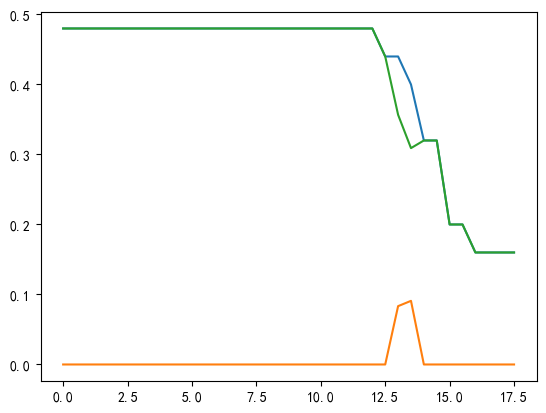

In [14]:
import seaborn 
seaborn.lineplot(x=wind_threshold, y=PODs)
seaborn.lineplot(x=wind_threshold, y=FARs)
seaborn.lineplot(x=wind_threshold, y=PODs-FARs)